# Spotted stars with harmonix

Long-baseline interferometers resolve the nearest giant stars well enough to map spots on their surfaces: CHARA/MIRC imaged the starspots of the RS CVn giant ζ Andromedae over a full rotation ([Roettenbacher et al. 2016](https://doi.org/10.1038/nature17444)). A natural model for such a star expands its surface brightness in spherical harmonics, as [jaxoplanet](https://github.com/exoplanet-dev/jaxoplanet) (after *starry*) does for light curves. [harmonix](https://github.com/shashankdholakia/harmonix) ([Dholakia & Pope 2025](https://arxiv.org/abs/2509.25433)) gives the interferometric visibilities of such a map analytically, including limb darkening and rotation, and differentiably in JAX.

`drpangloss` wraps a harmonix star in `HarmonixModel`, so that it works like any other source model: it simulates data, draws images on the sky, and is fitted through parameter paths. This tutorial builds a spotted, ζ And-like giant, draws it, looks at its visibilities, simulates three nights of CHARA-like data as it rotates, and fits the spot back.

harmonix and jaxoplanet are not dependencies of drpangloss. This page needs harmonix 0.1.0 or later, which runs on current JAX (jaxoplanet comes with it):

```bash
pip install "harmonix>=0.1.0"
```

Until 0.1.0 is on PyPI, install it from GitHub instead:

```bash
pip install "harmonix @ git+https://github.com/shashankdholakia/harmonix"
```

In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from jaxoplanet.starry import Surface, Ylm
from jaxoplanet.starry.visualization import show_surface
from jaxoplanet.starry.ylm import ylm_spot
from harmonix.harmonix import Harmonix

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from drpangloss.coverage import vlti_oidata
from drpangloss.fitting import fit
from drpangloss.likelihood import whitened_residuals
from drpangloss.models import HarmonixModel
from drpangloss.plotting import plot_model

# Importing harmonix turns on float64, which its solutions need.
print("float64:", jax.config.jax_enable_x64)

float64: True


## A spotted star

A jaxoplanet `Surface` holds the spherical-harmonic map (`y`), the orientation of the rotation axis (inclination `inc` from the line of sight, obliquity `obl` on the sky), the rotation `period` and polynomial limb-darkening coefficients `u`. `ylm_spot(ydeg)` expands a circular spot to degree `ydeg`: its arguments are the spot's contrast (1 for a black centre), its angular radius, and its latitude and longitude, all in radians.

`Harmonix(surface, radius)` adds the angular radius in milliarcseconds, and `HarmonixModel` makes it a drpangloss model observed at `observation_time` (in the same units as the period).

Our star is ζ And-like: a limb-darkened diameter of 2.54 mas, an inclination of 70°, and a rotation period of 17.8 days, with one large spot. Degree 8 resolves a spot of this size; higher degrees give sharper spots but slower fits.

In [2]:
ydeg = 8
spot = ylm_spot(ydeg)
period = 17.8  # days
inc, obl = jnp.radians(70.0), jnp.radians(25.0)
limb_darkening = [0.35, 0.2]


def spotted_star(contrast, size, lat, lon, radius):
    # A ζ And-like star with one spot; radius in mas, angles in radians.
    y = spot(contrast, size, lat, lon).todense()
    surface = Surface(
        y=Ylm.from_dense(y), inc=inc, obl=obl, period=period, u=limb_darkening
    )
    return Harmonix(surface, radius)


truth = dict(contrast=0.7, size=0.30, lat=0.45, lon=-1.0, radius=1.27)
star = spotted_star(**truth)
model = HarmonixModel(star, observation_time=0.0)

## Drawing the star

jaxoplanet's `show_surface` draws the map as a globe with a latitude–longitude graticule. It puts the surface's $x$ axis to the right, but harmonix's visibilities treat $x$ as East, so on the sky the globe appears mirrored; flipping the horizontal axis puts East to the left, the usual orientation. `HarmonixModel.render` (and so `plot_model`) draws the star on the sky directly, at its angular size, East left and North up, like every drpangloss model.

Over one rotation, the spot crosses the disk and disappears over the limb.

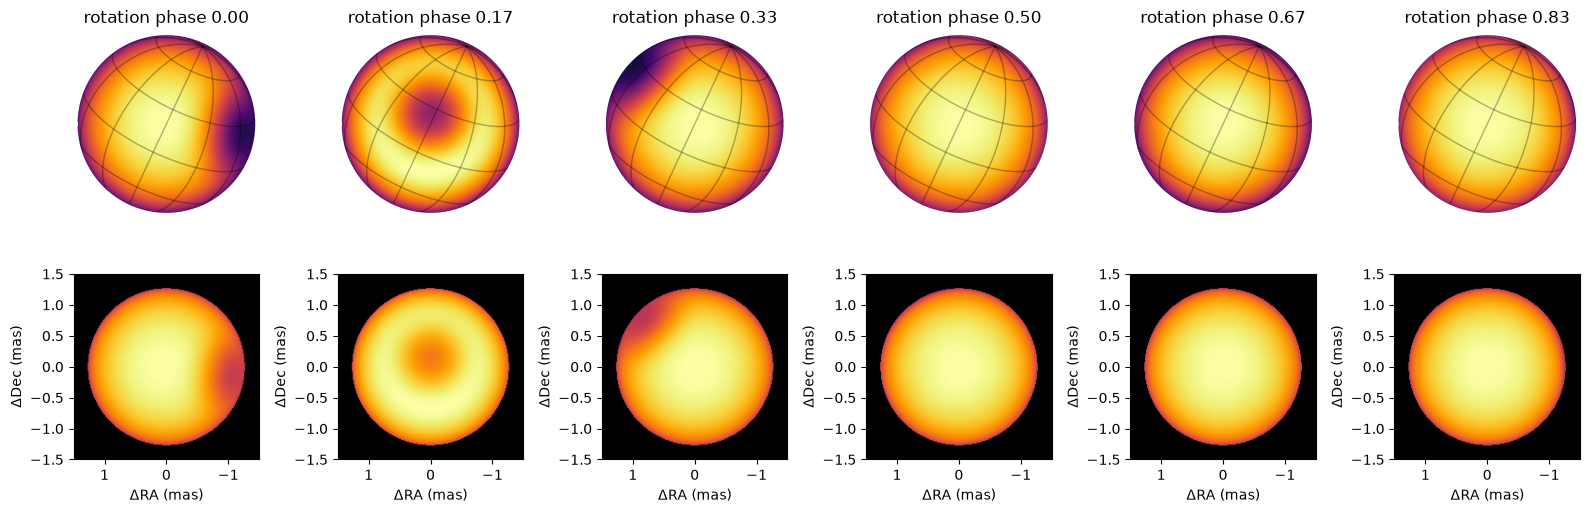

In [3]:
phases = np.linspace(0.0, 1.0, 6, endpoint=False)
fig, axes = plt.subplots(2, len(phases), figsize=(16, 5.6))
for ax_globe, ax_sky, phase in zip(axes[0], axes[1], phases):
    plt.sca(ax_globe)
    show_surface(star.surface, theta=2 * np.pi * phase, ax=ax_globe, res=300,
                 cmap="inferno")
    ax_globe.invert_xaxis()  # East to the left, as on the sky
    ax_globe.set_title(f"rotation phase {phase:.2f}")
    plot_model(HarmonixModel(star, observation_time=float(phase * period)),
               fov_mas=3.0, npix=200, ax=ax_sky, cmap="inferno")
plt.tight_layout()
plt.show()

## Visibilities in the uv plane

The Fourier transform of the star is what an interferometer measures. A limb-darkened disk's squared visibility is a set of circular lobes separated by nulls; the spot breaks this symmetry and gives the visibilities a phase. The white tracks are what six CHARA telescopes sample in the H band (1.5–1.8 µm) as ζ And (declination +24°) moves across the sky over ±3 hours. Baselines up to 330 m reach well into the second and third lobes, where the spot's signal is strongest.

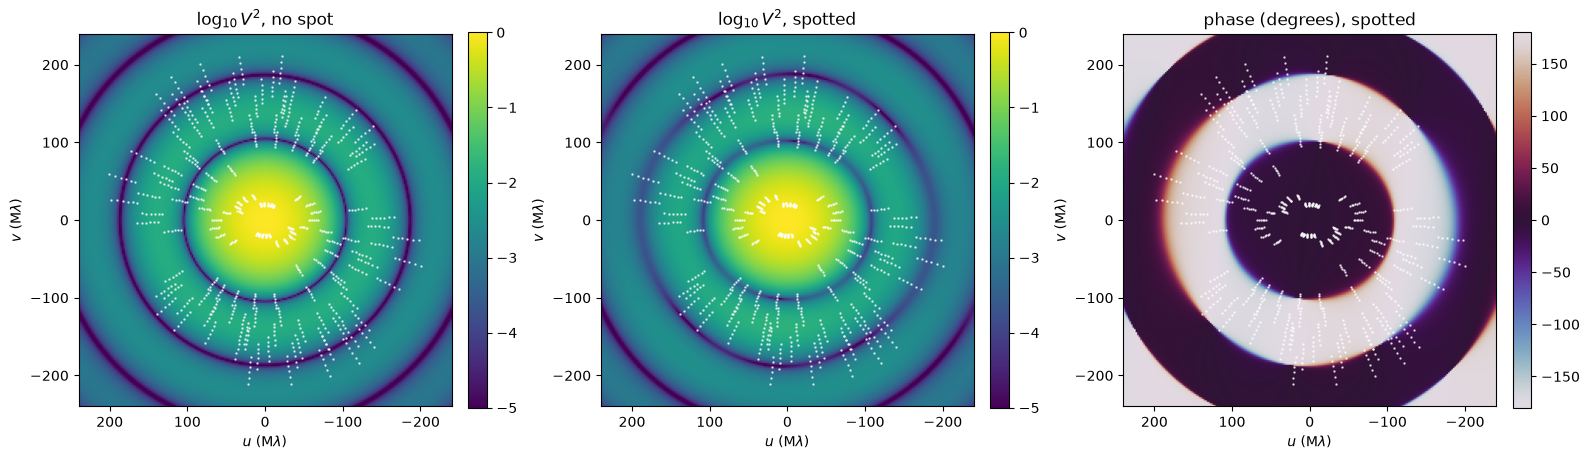

In [4]:
# Approximate CHARA station positions (East, North), metres.
chara = np.array([
    [0.0, 0.0], [-5.746, 33.580], [125.333, 305.928],
    [70.396, 269.716], [-175.073, 216.323], [-69.093, 199.342],
])
coverage = vlti_oidata(
    stations=chara,
    declination_deg=24.3,
    hour_angles_h=(-3.0, -1.5, 0.0, 1.5, 3.0),
    wavelengths_m=np.linspace(1.5e-6, 1.8e-6, 6),
    sigma_v2=0.01,
    sigma_cp_deg=1.0,
    latitude_deg=34.2,
)

plain_star = Harmonix(
    Surface(inc=inc, obl=obl, period=period, u=limb_darkening), truth["radius"]
)
lim, n = 2.4e8, 241  # spatial frequencies in wavelengths (rad^-1)
uu, vv = np.meshgrid(np.linspace(-lim, lim, n), np.linspace(-lim, lim, n))
v_plain = np.asarray(HarmonixModel(plain_star, observation_time=0.0).model(uu, vv, 1.0))
v_spot = np.asarray(model.model(uu, vv, 1.0))

panels = [
    (np.log10(np.abs(v_plain) ** 2), r"$\log_{10} V^2$, no spot",
     dict(cmap="viridis", vmin=-5, vmax=0)),
    (np.log10(np.abs(v_spot) ** 2), r"$\log_{10} V^2$, spotted",
     dict(cmap="viridis", vmin=-5, vmax=0)),
    (np.degrees(np.angle(v_spot)), "phase (degrees), spotted",
     dict(cmap="twilight", vmin=-180, vmax=180)),
]
u_track = np.asarray(coverage.u / coverage.wavel) / 1e6
v_track = np.asarray(coverage.v / coverage.wavel) / 1e6
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (image, title, style) in zip(axes, panels):
    shown = ax.imshow(image, origin="lower", extent=[-lim / 1e6, lim / 1e6] * 2,
                      **style)
    ax.invert_xaxis()  # East to the left
    for sign in (1, -1):
        ax.plot(sign * u_track, sign * v_track, ".", ms=1.5, color="w",
                alpha=0.7)
    ax.set(xlabel=r"$u$ (M$\lambda$)", ylabel=r"$v$ (M$\lambda$)", title=title)
    fig.colorbar(shown, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Three nights of data

We observe on three nights, three days apart, while the spot crosses the visible hemisphere, with errors of 0.01 on the squared visibilities and 1° on the closure phases. `with_model` fills in the coverage with the model's observables plus noise; `observation_time` sets the star's rotation for each night.

The squared visibilities mostly measure the star's size and limb darkening, and differ little from those of an unspotted star. The closure phases carry the spot: an unspotted, centrally symmetric star has closure phases of exactly 0° or 180°, so every departure from those is the spot, and it changes as the star turns.

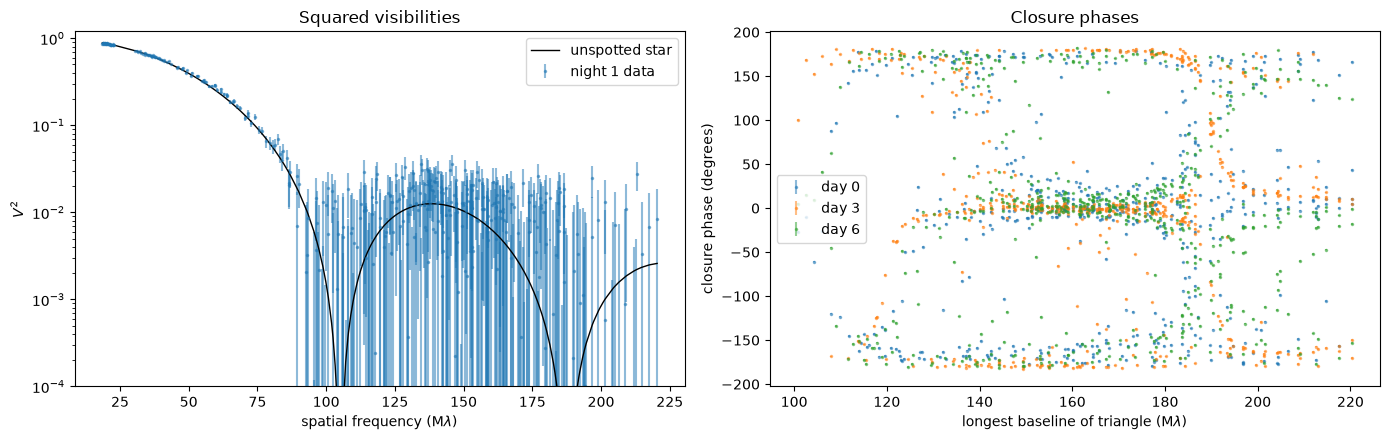

In [5]:
nights = (0.0, 3.0, 6.0)  # days


def observe(star):
    return [HarmonixModel(star, observation_time=t) for t in nights]


data = [
    coverage.with_model(m, key=jax.random.PRNGKey(i))
    for i, m in enumerate(observe(star))
]

fig, (ax_v2, ax_cp) = plt.subplots(1, 2, figsize=(14, 4.5))
spatial_freq = np.asarray(np.hypot(coverage.u, coverage.v) / coverage.wavel) / 1e6
order = np.argsort(spatial_freq)
plain_v2 = np.asarray(HarmonixModel(plain_star, observation_time=0.0).model(
    coverage.u, coverage.v, coverage.wavel))
ax_v2.errorbar(spatial_freq, np.asarray(data[0].vis),
               yerr=np.asarray(data[0].d_vis), fmt=".", ms=3, alpha=0.5,
               label="night 1 data")
ax_v2.plot(spatial_freq[order], np.abs(plain_v2[order]) ** 2, "k-", lw=1,
           label="unspotted star")
ax_v2.set(yscale="log", ylim=(1e-4, 1.2), xlabel=r"spatial frequency (M$\lambda$)",
          ylabel=r"$V^2$", title="Squared visibilities")
ax_v2.legend()

# Closure phases against the longest baseline of their triangle.
triangle_freq = np.max(np.stack([
    spatial_freq[np.asarray(data[0].i_cps1)],
    spatial_freq[np.asarray(data[0].i_cps2)],
    spatial_freq[np.asarray(data[0].i_cps3)],
]), axis=0)
for night, d in zip(nights, data):
    ax_cp.errorbar(triangle_freq, np.degrees(np.asarray(d.phi)),
                   yerr=np.degrees(np.asarray(d.d_phi)), fmt=".", ms=3,
                   alpha=0.5, label=f"day {night:g}")
ax_cp.set(xlabel=r"longest baseline of triangle (M$\lambda$)",
          ylabel="closure phase (degrees)", title="Closure phases")
ax_cp.legend()
plt.tight_layout()
plt.show()

## Fitting the star

The data constrain the stellar radius extremely tightly, because they sample several visibility lobes: a 1% error in the radius moves the nulls past many data points. The χ² surface in radius therefore has many narrow minima, and a local optimizer must start close to the right one. So we fit in two steps, as one would with real data.

First, the radius: scan χ² for an unspotted, limb-darkened star over a range of radii. Each evaluation takes about a millisecond, so a fine grid is cheap.

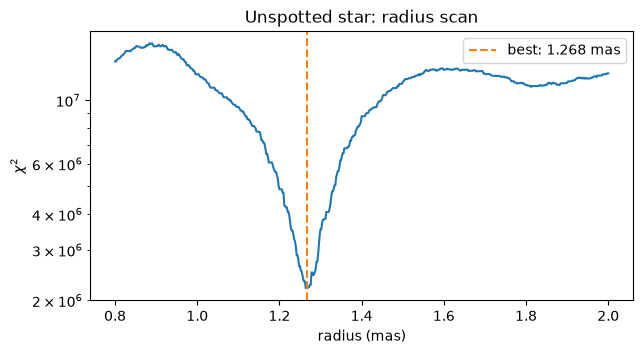

In [6]:
def chi2_unspotted(radius):
    plain = Harmonix(Surface(inc=inc, obl=obl, period=period, u=limb_darkening),
                     radius)
    return sum(
        jnp.sum(whitened_residuals(HarmonixModel(plain, observation_time=t), d) ** 2)
        for t, d in zip(nights, data)
    )


radii = jnp.linspace(0.8, 2.0, 601)
chi2 = jax.jit(jax.vmap(chi2_unspotted))(radii)
radius_guess = float(radii[jnp.argmin(chi2)])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(radii, chi2)
ax.axvline(radius_guess, color="C1", ls="--", label=f"best: {radius_guess:.3f} mas")
ax.set(yscale="log", xlabel="radius (mas)", ylabel=r"$\chi^2$",
       title="Unspotted star: radius scan")
ax.legend()
plt.show()

Then the spot. `fit` accepts a function of the parameters that returns one model per dataset, so the three nights share one star seen at three rotation phases. We start the spot far from its true position. (Its latitude and longitude should not start at exactly zero: jaxoplanet's rotation of the spot expansion has zero gradient there.) Every step differentiates through jaxoplanet's spot expansion and harmonix's analytic visibilities.

In [7]:
priors = dict(
    contrast=dist.Uniform(0.0, 1.0),
    size=dist.Uniform(0.05, 0.8),
    lat=dist.Uniform(-1.5, 1.5),
    lon=dist.Uniform(-np.pi, np.pi),
    radius=dist.Uniform(1.0, 1.6),
)
init = dict(contrast=0.5, size=0.2, lat=0.2, lon=0.1, radius=radius_guess)


def scene(**params):
    return observe(spotted_star(**params))


result = fit(scene, priors, data, init=init, method="lbfgs")
print(f"reduced chi2 = {result.info['chi2_red']:.2f} "
      f"after {result.info['steps']} steps")
for name in priors:
    print(f"{name:>8}: start {init[name]:6.3f}   fit {float(result.values[name]):6.3f}"
          f"   truth {truth[name]:6.3f}")

reduced chi2 = 1.04 after 233 steps
contrast: start  0.500   fit  0.699   truth  0.700
    size: start  0.200   fit  0.300   truth  0.300
     lat: start  0.200   fit  0.450   truth  0.450
     lon: start  0.100   fit -1.000   truth -1.000
  radius: start  1.268   fit  1.270   truth  1.270


The fit recovers the spot and the radius. Drawing the fitted star next to the true one on each night:

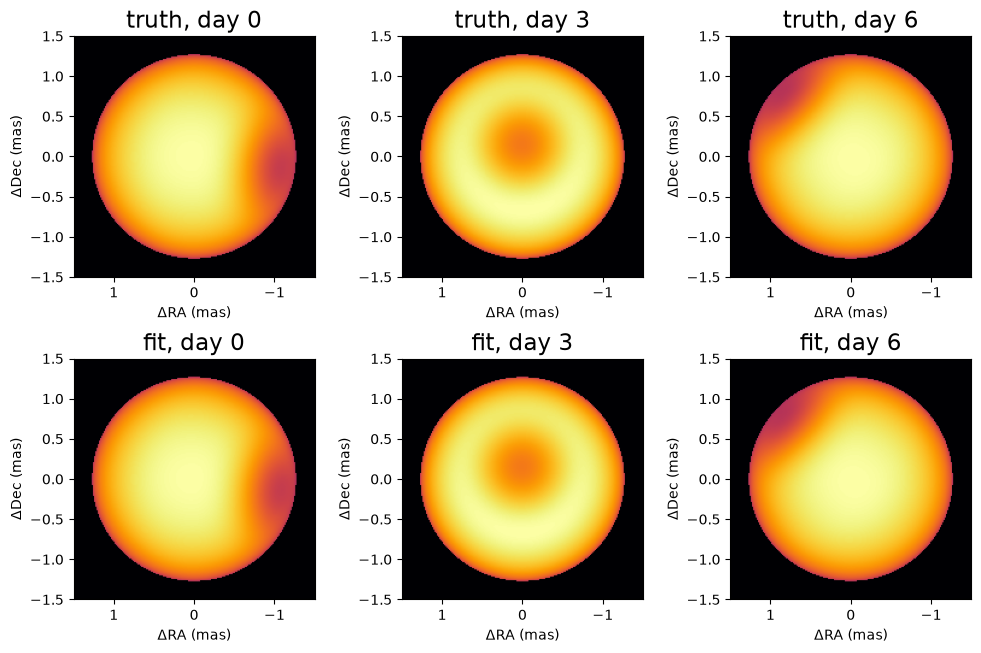

In [8]:
fitted = spotted_star(**{k: result.values[k] for k in priors})
fig, axes = plt.subplots(2, len(nights), figsize=(10, 6.6))
for column, night in enumerate(nights):
    for row, (label, s) in enumerate([("truth", star), ("fit", fitted)]):
        plot_model(HarmonixModel(s, observation_time=night), fov_mas=3.0,
                   npix=200, ax=axes[row, column], cmap="inferno",
                   title=f"{label}, day {night:g}")
plt.tight_layout()
plt.show()

## Notes

- `HarmonixModel`'s parameters are reached through the wrapped star: `"source.radius"` (mas) and `"source.data"`, harmonix's map coefficients for $l \geq 1$ relative to $Y_{0,0}$. A template `HarmonixModel` can be fitted through these paths directly, e.g. to map the surface coefficient by coefficient with regularisation; here we fitted the spot's physical parameters through a function instead.
- harmonix's visibilities are normalised to 1 at zero baseline, so a harmonix star has weight 1 inside a [`System`](composition.md), where it can be combined with companions or disks and drawn.
- jaxoplanet's pictures put East on the right; flip them (as above) to compare with the sky, or use `plot_model`.